In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np 
import scipy 
import scipy.stats as stats

# Exercice 1 : Support d'une variable uniforme

In [3]:
unitheta = np.loadtxt("unitheta.csv",
                 delimiter=",", dtype=float)

2. Estimateurs 

In [4]:
theta_empirique = 0
for i in range(0, len(unitheta)):
    theta_empirique += unitheta[i]

theta_empirique = theta_empirique/500
print("Theta empirique = ", theta_empirique)

Theta empirique =  13.4669169387596


In [5]:
theta_vraisemblance = max(unitheta)
print("Theta vraisemblance = ", theta_vraisemblance)

Theta vraisemblance =  12.982513935863368


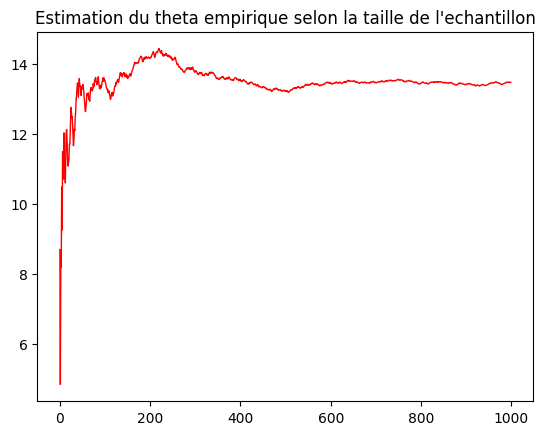

In [6]:
y = 2*np.cumsum(unitheta)/np.arange(1,1001)
x = np.arange(0,1000)

plt.title("Estimation du theta empirique selon la taille de l'echantillon")
plt.plot(x, y, color="red", linewidth=1)


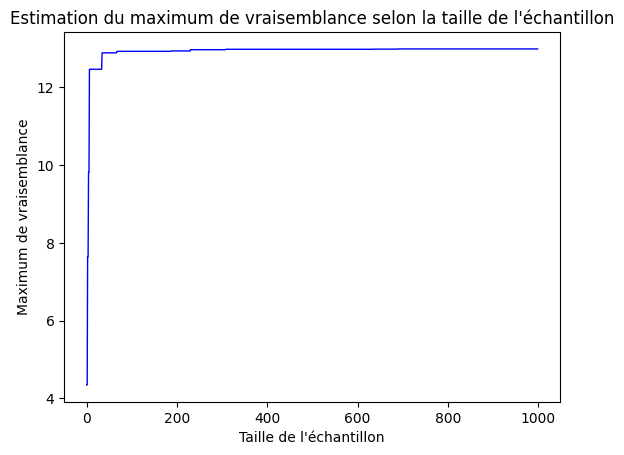

In [7]:
Y = np.zeros(1000)
for i in range(0,1000):
    Y[i] = max(unitheta[0:i+1])

plt.title("Estimation du maximum de vraisemblance selon la taille de l'échantillon")
plt.xlabel("Taille de l'échantillon")
plt.ylabel("Maximum de vraisemblance")
plt.plot(x, Y, color="blue", linewidth=1)

Estimateur MV : convergence exponentielle.
Estimateur Moments : Appliquer le TCL.

Intervalles de confiance pour les estimateurs : 

In [22]:
n = 1000
alpha = 0.1

print("Theta empirique : "," ICA(5%) = [",theta_empirique*(1-1.645/np.sqrt(3*n))," ; ",theta_empirique*(1+1.645/np.sqrt(3*n)),"]")
print("Theta vraisemblance : "," ICA(5%) = [",theta_vraisemblance," ; ",theta_vraisemblance/np.power(alpha,1/n),"]")




Theta empirique :   ICA(5%) = [ 13.062458914150112  ;  13.871374963369085 ]
Theta vraisemblance :   ICA(5%) = [ 12.982513935863368  ;  13.012441721335184 ]


# Exercice 2 : Quantiles empiriques

On va illuster le fait que la convergence est forte et que le quantile empirique est asympotiquement normal dans une même boucle.

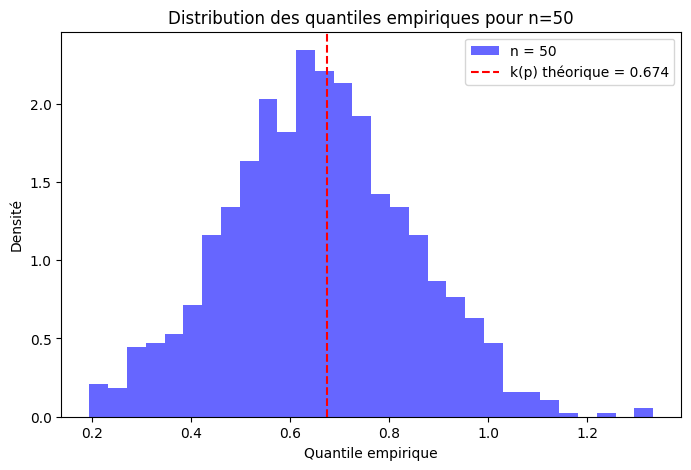

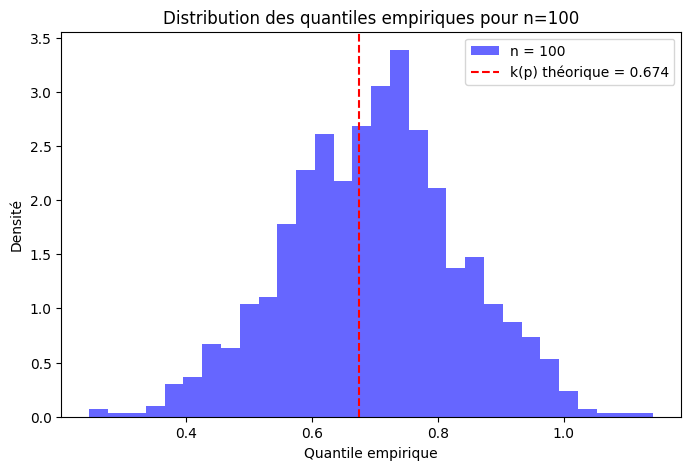

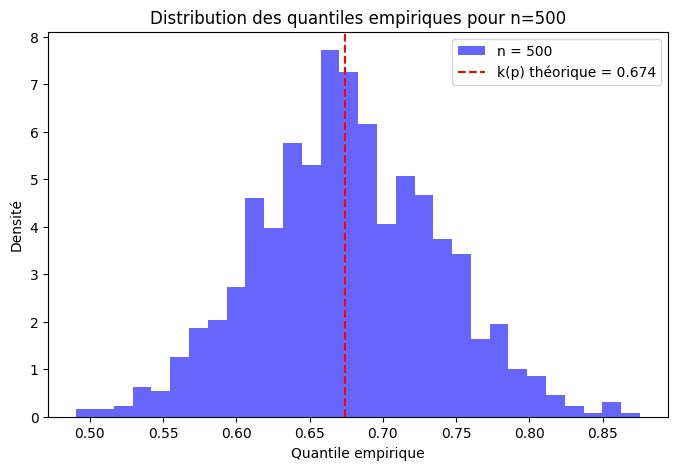

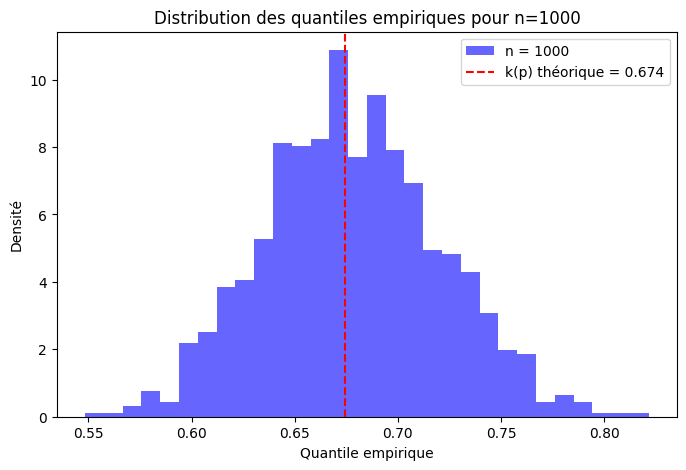

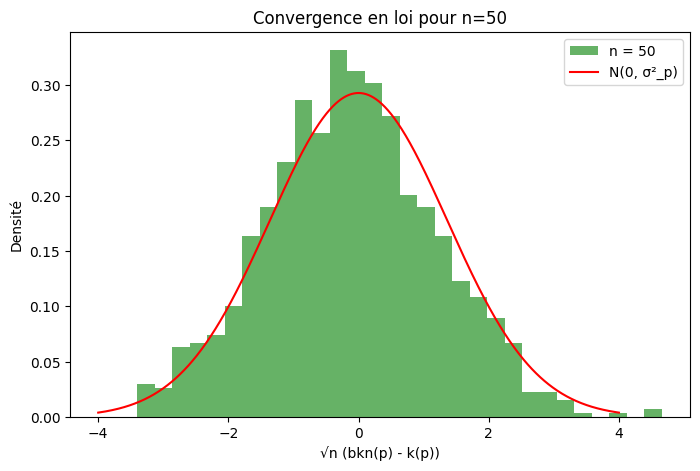

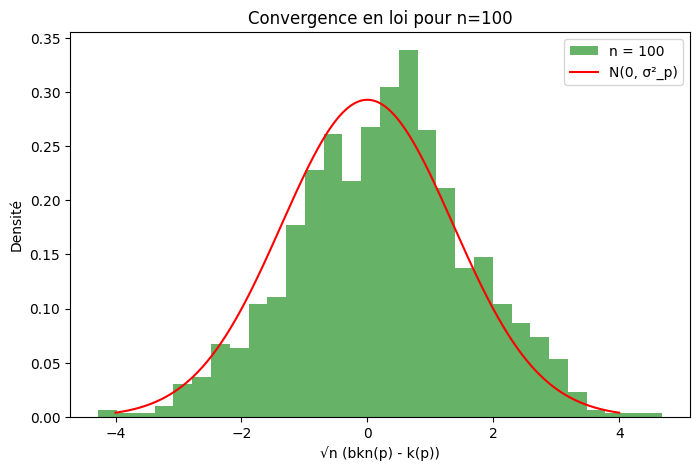

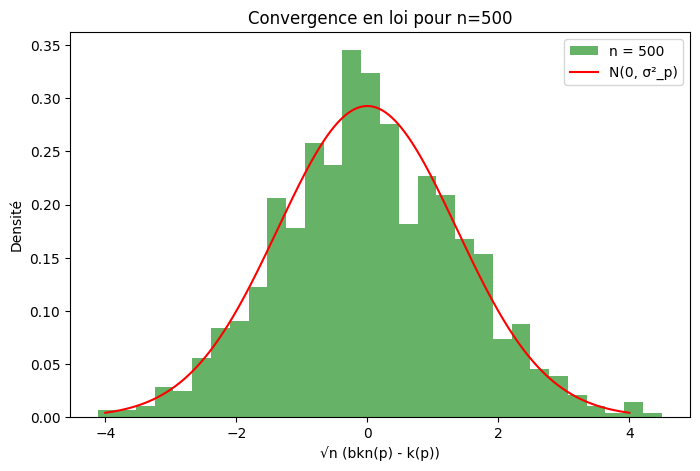

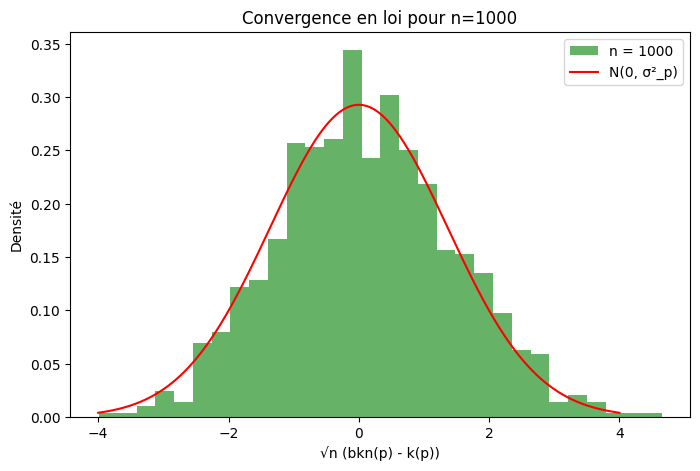

In [40]:
from scipy.stats import norm

n_values = [50, 100, 500, 1000]  # Tailles d'échantillons
p = 0.75  # Quantile d'ordre p
N_simulations = 1000 

# Valeurs théoriques (via la librairie scipy)
k_p = norm.ppf(p)  # Quantile théorique d'ordre p
f_kp = norm.pdf(k_p)  # Densité de la loi normale au quantile théorique


valeurs_empiriques = []

# Simulation
for n in n_values:
    quantiles_empiriques = []
    for _ in range(N_simulations):
        # Génération d'un échantillon de taille n
        sample = np.random.normal(0, 1, n)
        
        sample_sorted = np.sort(sample)
        # Quantile empirique
        empirical_quantile = sample_sorted[int(np.floor(n * p))]
        quantiles_empiriques.append(empirical_quantile)

    # Stock des quantiles empiriques pour cette taille n
    valeurs_empiriques.append(quantiles_empiriques)

    # Graphes pour la convergence forte
    plt.figure(figsize=(8, 5))
    plt.hist(quantiles_empiriques, bins=30, density=True, alpha=0.6, color='blue', label=f'n = {n}')
    plt.axvline(k_p, color='red', linestyle='--', label=f'k(p) théorique = {k_p:.3f}')
    plt.title(f"Distribution des quantiles empiriques pour n={n}")
    plt.xlabel("Quantile empirique")
    plt.ylabel("Densité")
    plt.legend()
    plt.show()

# Graphe pour la convergence en loi
for i, n in enumerate(n_values):
    quantiles_empiriques_normalisés = np.sqrt(n) * (np.array(valeurs_empiriques[i]) - k_p)
    plt.figure(figsize=(8, 5))
    plt.hist(quantiles_empiriques_normalisés, bins=30, density=True, alpha=0.6, color='green', label=f'n = {n}')
    # Superposition de la densité normale asymptotique
    x = np.linspace(-4, 4, 1000)
    plt.plot(x, norm.pdf(x, 0, np.sqrt(p * (1 - p)) / f_kp), 'r-', label='N(0, σ²_p)')
    plt.title(f"Convergence en loi pour n={n}")
    plt.xlabel("√n (bkn(p) - k(p))")
    plt.ylabel("Densité")
    plt.legend()
    plt.show()


# Exercice 3 : Estimation gaussienne

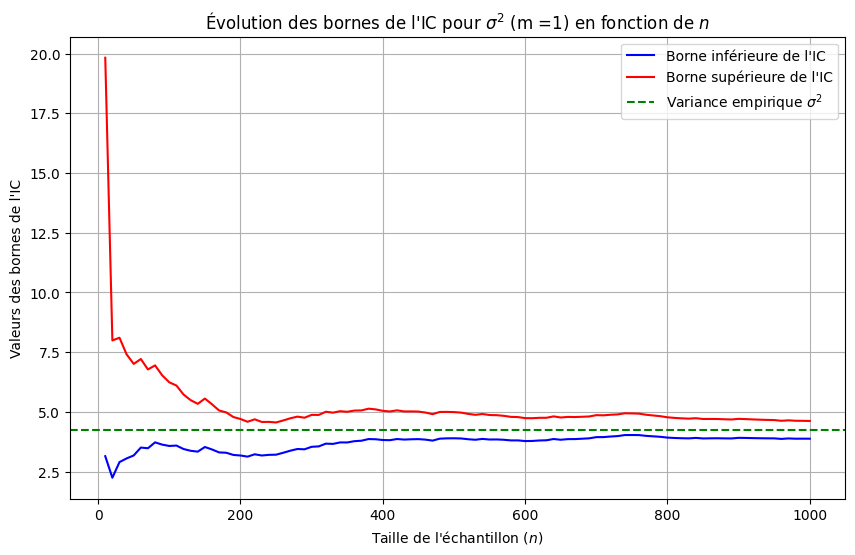

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

# Chargement des données
x = np.loadtxt("gaussiennes.csv", delimiter=",", dtype=float)
n_values = np.arange(10, len(x) + 1, 10)  # Tailles d'échantillons croissantes, de 10 en 10
alpha = 0.05
m = 1  # m est connu

# stock des bornes inf et sup de l'ICA
lower_bounds = []
upper_bounds = []

# Calcul des IC pour chaque taille d'échantillon
for n in n_values:
    sample = x[:n]  # Sous-échantillon de taille n
    S2_m_known = np.sum((sample - m) ** 2)     # Estimation de la variance
    chi2_lower = chi2.ppf(alpha / 2, df=n)     # Quantile d'ordre alpha/2 de la loi du chi2
    chi2_upper = chi2.ppf(1 - alpha / 2, df=n) # Quantile d'ordre 1-alpha/2 de la loi du chi2
    lower_bound = S2_m_known / chi2_upper      # Borne inférieure de l'IC
    upper_bound = S2_m_known / chi2_lower      # Borne supérieure de l'IC
    lower_bounds.append(lower_bound)           # Stockage des bornes
    upper_bounds.append(upper_bound)

# Tracé des bornes des IC
plt.figure(figsize=(10, 6))
plt.plot(n_values, lower_bounds, label="Borne inférieure de l'IC", color="blue")
plt.plot(n_values, upper_bounds, label="Borne supérieure de l'IC", color="red")
plt.axhline(y=np.var(x), color="green", linestyle="--", label="Variance empirique $\sigma^2$")
plt.title("Évolution des bornes de l'IC pour $\sigma^2$ (m =1) en fonction de $n$")
plt.xlabel("Taille de l'échantillon ($n$)")
plt.ylabel("Valeurs des bornes de l'IC")
plt.legend()
plt.grid()
plt.show()


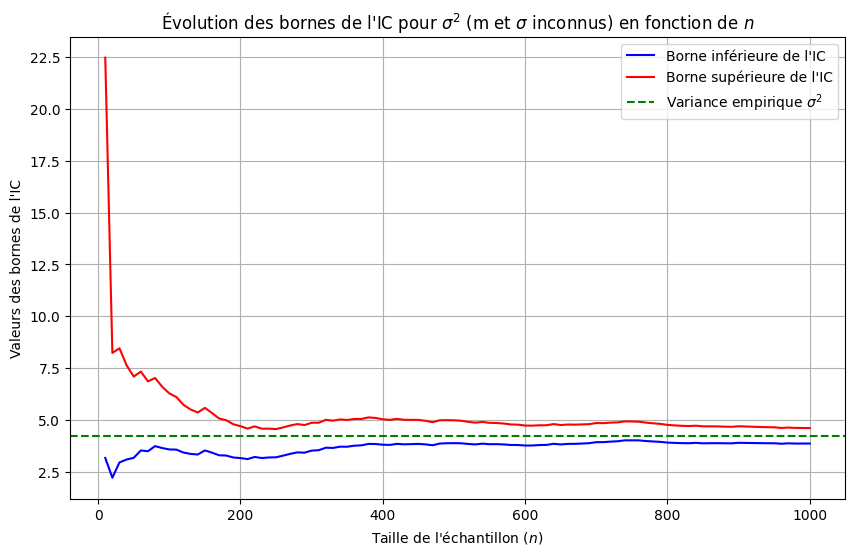

In [51]:
"""
Lorsque m est inconnu, on doit estimer m par la moyenne empirique. 
Dans ce cas, on doit utiliser la variance corrigée pour estimer la variance de l'échantillon.
On ajuste donc les degrés de liberté du chi2 pour obtenir les quantiles de la loi du chi2."""

# Listes pour stocker les bornes inférieures et supérieures des IC
lower_bounds = []
upper_bounds = []

# Calcul des IC pour chaque taille d'échantillon
for n in n_values:
    sample = x[:n]  # Sous-échantillon de taille n
    sample_mean = np.mean(sample)                                 # Moyenne empirique
    S2_m_unknown = np.sum((sample - sample_mean) ** 2) / (n - 1)  # Variance corrigée
    chi2_lower = chi2.ppf(alpha / 2, df=n - 1)                    # Quantile d'ordre alpha/2 de la loi du chi2
    chi2_upper = chi2.ppf(1 - alpha / 2, df=n - 1)                # Quantile d'ordre 1-alpha/2 de la loi du chi2
    lower_bound = S2_m_unknown * (n - 1) / chi2_upper
    upper_bound = S2_m_unknown * (n - 1) / chi2_lower
    lower_bounds.append(lower_bound)
    upper_bounds.append(upper_bound)

# Tracé des bornes des IC
plt.figure(figsize=(10, 6))
plt.plot(n_values, lower_bounds, label="Borne inférieure de l'IC", color="blue")
plt.plot(n_values, upper_bounds, label="Borne supérieure de l'IC", color="red")
plt.axhline(y=np.var(x, ddof=1), color="green", linestyle="--", label="Variance empirique $\sigma^2$")
plt.title("Évolution des bornes de l'IC pour $\sigma^2$ (m et $\sigma$ inconnus) en fonction de $n$")
plt.xlabel("Taille de l'échantillon ($n$)")
plt.ylabel("Valeurs des bornes de l'IC")
plt.legend()
plt.grid()
plt.show()


3. La variable présentée suit une loi de Student à n-1 ddl. Traçons l'intervalle de confiance pour la moyenne m en fonction de la taille de l'échantillon considéré.

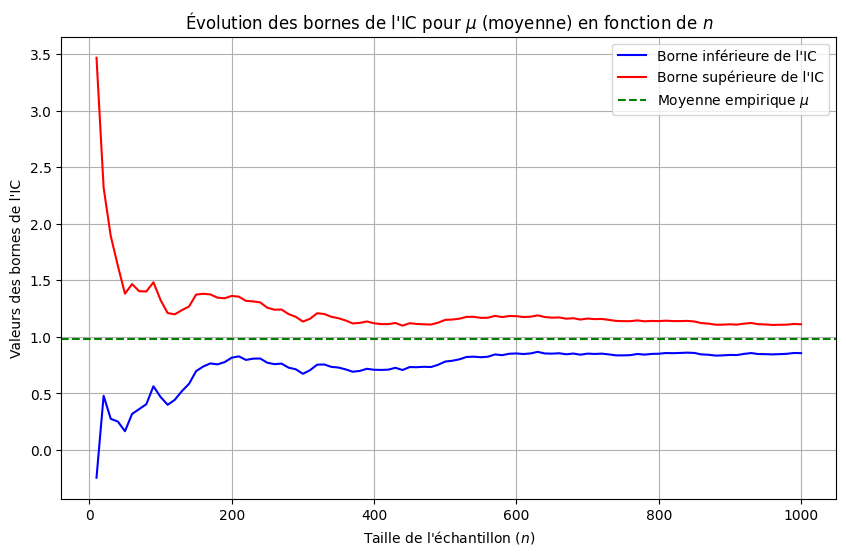

In [52]:
from scipy.stats import t # Importation de la loi de Student

# Listes pour stocker les bornes inférieures et supérieures des IC
lower_bounds = []
upper_bounds = []

# Calcul des IC pour chaque taille d'échantillon
for n in n_values:
    sample = x[:n]  # Sous-échantillon de taille n
    sample_mean = np.mean(sample)                               # Moyenne empirique
    S = np.sqrt(np.sum((sample - sample_mean) ** 2) / (n - 1))  # Écart-type corrigé
    t_critical = t.ppf(1 - alpha / 2, df=n - 1)                 # Quantile de la loi de Student
    margin = t_critical * S / np.sqrt(n)                         # Erreur
    lower_bounds.append(sample_mean - margin)
    upper_bounds.append(sample_mean + margin)

# Tracé des bornes des IC
plt.figure(figsize=(10, 6))
plt.plot(n_values, lower_bounds, label="Borne inférieure de l'IC", color="blue")
plt.plot(n_values, upper_bounds, label="Borne supérieure de l'IC", color="red")
plt.axhline(y=np.mean(x), color="green", linestyle="--", label="Moyenne empirique $\mu$")
plt.title("Évolution des bornes de l'IC pour $\mu$ (moyenne) en fonction de $n$")
plt.xlabel("Taille de l'échantillon ($n$)")
plt.ylabel("Valeurs des bornes de l'IC")
plt.legend()
plt.grid()
plt.show()


# Exercice 4 : Estimation exponentielle

À la main, on trouve que l'estimateur du max de vraisemblance de la moyenne $\frac{1}{\lambda}$ est :  $$\frac{\sum_{i=1}^{n}y_i}{n}$$ Cet estimateur suit une loi du ${\chi}^2$ à $2n$ ddl.


In [54]:
# Chargement des données
y = np.loadtxt("expolambda.csv", delimiter=",", dtype=float)
n = len(y)
alpha = 0.05

# Somme des observations
sum_y = np.sum(y)

# Quantiles de la loi chi2
chi2_lower = chi2.ppf(alpha / 2, df=2 * n)
chi2_upper = chi2.ppf(1 - alpha / 2, df=2 * n)

# Calcul des bornes de l'IC
lambda_lower = chi2_lower / (2 * sum_y)
lambda_upper = chi2_upper / (2 * sum_y)

# Affichage des résultats
print(f"Intervalle de confiance pour λ à 95% : [{lambda_lower:.4f}, {lambda_upper:.4f}]")

Intervalle de confiance pour λ à 95% : [0.4504, 0.5098]


# Exercice 6 : Référendum

In [62]:
y = np.loadtxt("bernou.csv", delimiter=",", dtype=float)
# Nombre d'observations
n = len(y)

# Estimation du paramètre p par le maximum de vraisemblance
p_hat = np.mean(y)

# Intervalle de confiance asymptotique de 95% pour p
ci_lower = p_hat - 1.96 * np.sqrt(p_hat * (1 - p_hat) / n)
ci_upper = p_hat + 1.96 * np.sqrt(p_hat * (1 - p_hat) / n)

# Affichage des résultats
print(f"Estimateur du maximum de vraisemblance de p : {p_hat}")
print(f"Intervalle de confiance asymptotique à 95% pour p : [{ci_lower}, {ci_upper}]")


Estimateur du maximum de vraisemblance de p : 0.292
Intervalle de confiance asymptotique à 95% pour p : [0.26381849866313006, 0.3201815013368699]
